In [2]:
import gc
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from utils.analysis import *

### Dataset names and paths

In [ ]:
datasets = [
    "Sparsim_Ear",
    "Sparsim_Skin",
    "SymSim",
    "Ear",
    "Skin",
    "Lung",
    "Splat",
]

OUTPUT_DIRS  = [
    # Sparsim_Ear
    "outputs/Sparsim_Ear/Pavel/Results/", 
    "outputs/Sparsim_Ear/SPARSim/Results/",
    "outputs/Sparsim_Ear/Splat/Results/",
    "outputs/Sparsim_Ear/Zinbwave/Results/",
    "outputs/Sparsim_Ear/SymSim/Results/",
    "outputs/Sparsim_Ear/ESCO/Results/",
    "outputs/Sparsim_Ear/SPARSimvarlib/Results/",
    "outputs/Sparsim_Ear/Random/Results/",
    # Sparsim_Skin 
    "outputs/Sparsim_Skin/Pavel/Results/", 
    "outputs/Sparsim_Skin/SPARSim/Results/",
    "outputs/Sparsim_Skin/Splat/Results/",
    "outputs/Sparsim_Skin/Zinbwave/Results/",
    "outputs/Sparsim_Skin/SymSim/Results/",
    "outputs/Sparsim_Skin/ESCO/Results/",
    "outputs/Sparsim_Skin/SPARSimvarlib/Results/",
    "outputs/Sparsim_Skin/Random/Results/",
    # SymSim
    "outputs/SymSim/Pavel/Results/", 
    "outputs/SymSim/SPARSim/Results/",
    "outputs/SymSim/Splat/Results/",
    "outputs/SymSim/Zinbwave/Results/",
    "outputs/SymSim/SymSim/Results/",
    "outputs/SymSim/ESCO/Results/",
    "outputs/SymSim/SPARSimvarlib/Results/",
    "outputs/SymSim/Random/Results/",
    # Ear 
    "outputs/Ear/Pavel/Results/", 
    "outputs/Ear/SPARSim/Results/",
    "outputs/Ear/Splat/Results/",
    "outputs/Ear/Zinbwave/Results/",
    "outputs/Ear/SymSim/Results/",
    "outputs/Ear/ESCO/Results/",
    "outputs/Ear/SPARSimvarlib/Results/",
    "outputs/Ear/Random/Results/",
    # Skin
    "outputs/Skin/Pavel/Results/", 
    "outputs/Skin/SPARSim/Results/",
    "outputs/Skin/Splat/Results/",
    "outputs/Skin/Zinbwave/Results/",
    "outputs/Skin/SymSim/Results/",
    "outputs/Skin/ESCO/Results/",
    "outputs/Skin/SPARSimvarlib/Results/",
    "outputs/Skin/Random/Results/",
    # Lung 
    "outputs/Lung/Pavel/Results/", 
    "outputs/Lung/SPARSim/Results/",
    "outputs/Lung/Splat/Results/",
    "outputs/Lung/Zinbwave/Results/",
    "outputs/Lung/SymSim/Results/",
    "outputs/Lung/ESCO/Results/",
    "outputs/Lung/SPARSimvarlib/Results/",
    "outputs/Lung/Random/Results/",
    # Splat
    "outputs/Splat/Pavel/Results/", 
    "outputs/Splat/SPARSim/Results/",
    "outputs/Splat/Splat/Results/",
    "outputs/Splat/Zinbwave/Results/",
    "outputs/Splat/SymSim/Results/",
    "outputs/Splat/ESCO/Results/",
    "outputs/Splat/SPARSimvarlib/Results/",
    "outputs/Splat/Random/Results/",
]

### Load all result files

In [ ]:
all_results = []

for output_dir in OUTPUT_DIRS:
    paths = find_pickle_files(output_dir)

    # Match a directory name from the path and rename it
    path_parts = Path(output_dir).parts

    # Infer the dataset from the directory path
    dataset = next(
        (part for part in path_parts if part in datasets),
        "Unknown",
    )

    print(f"{dataset}: found {len(paths)} pickle files in {output_dir}")

    for i, file in enumerate(paths):

        try: 
            # Load the object
            obj = joblib.load(file)

            # Extract parameters from filename
            base_info = extract_params(file)
            full_info = extend_with_attributes(obj, base_info)

            # Create a small row containing only what we need
            row = {
                "dataset": dataset,
                "source_path": output_dir,
                "method": full_info.get("method"),
            }

            # Parse the small dictionaries immediately
            timings = parse_params(full_info.get("timings"))
            parameters = parse_params(full_info.get("parameters"))
            additional = parse_params(full_info.get("additional"))

            # Add everything directly as columns
            if isinstance(timings, dict):
                for key, value in timings.items():
                    row[key] = value

            if isinstance(parameters, dict):
                for key, value in parameters.items():
                    row[f"param_{key}"] = value

            if isinstance(additional, dict):
                for key, value in additional.items():
                    row[f"additional_{key}"] = value

            all_results.append(row)

            # Release references to all of the large arrays/objects
            del full_info
            del obj

            # Occasionally release unused memory
            if i % 100 == 0:
                gc.collect()

        except MemoryError:
            print(f"MEMORY ERROR while loading: {file}")
            gc.collect()
            raise

        except Exception as e:
            print(f"Could not load {file}: {e}")

# Final cleanup
gc.collect()

# Create DataFrame
dropout_results = pd.DataFrame(all_results)

print(f"Total loaded results: {len(dropout_results)}")

SymSim: found 1330 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/Alisa/2026-04-26/


/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/.conda-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/.conda-env/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/.conda-env/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


SymSim: found 1470 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/SPARSim/2026-08-20/
SymSim: found 1400 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/Splat/2026-07-06/
SymSim: found 1470 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/Zinbwave/2026-05-31/
SymSim: found 1330 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/SymSim/2026-04-30/
SymSim: found 1470 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/ESCO/2026-07-07/
SymSim: found 1470 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/SPARSimvarlib/2026-07-08/
SymSim: found 1400 pickle files in /dtu-compute/digitstem/zuzanna/outputs/New_experiment_28_03_2026/SymSim10000/Random/2026-06-21/
Total loaded results: 11340


### Check the loaded data

In [5]:
print(dropout_results.shape)
print(dropout_results.columns.tolist())

print("\nMethods:")
print(dropout_results["method"].value_counts(dropna=False))

print("\nDatasets:")
print(dropout_results["dataset"].value_counts(dropna=False))

(11340, 22)
['dataset', 'source_path', 'method', 'preprocess', 'fit', 'get_latent', 'tsne', 'umap', 'leiden', 'param_n_latent', 'param_n_hidden', 'param_n_layers', 'param_likelihood', 'param_n_epochs', 'param_highly_variable_genes', 'param_batch_size', 'param_device', 'additional_training_history', 'param_n_components', 'param_normalize_total', 'param_log1p', 'param_scale']

Methods:
method
pca     6480
scvi    4860
Name: count, dtype: int64

Datasets:
dataset
SymSim    11340
Name: count, dtype: int64


### Prepare timing data

In [6]:
df = dropout_results.copy()

# Define step columns and meta
step_cols = [
    "preprocess",
    "fit",
    "get_latent",
    "umap",
    "leiden",
]

pipeline_col = "method"

# Ensure timing columns exist and are numeric
for step in step_cols:
    if step not in df.columns:
        df[step] = pd.NA

    df[step] = pd.to_numeric(df[step], errors="coerce")

# Replace exact zero runtimes so they can be shown on a log scale
df[step_cols] = df[step_cols].replace(0, 1e-3)

# Calculate total runtime for each individual experiment
df["total_runtime"] = df[step_cols].sum(axis=1, min_count=1)

display(
    df[
        [
            "dataset",
            "method",
            "preprocess",
            "fit",
            "get_latent",
            "umap",
            "leiden",
            "total_runtime",
        ]
    ].head()
)

,dataset,method,preprocess,fit,get_latent,umap,leiden,total_runtime
0,SymSim,scvi,0.042926,160.900438,0.298599,16.405917,3.417860,181.065740
1,SymSim,scvi,0.051011,197.743293,0.463354,16.242030,2.877387,217.377074
2,SymSim,scvi,0.033644,143.093842,0.191513,16.361214,5.306796,164.987009
3,SymSim,scvi,0.055321,197.595936,0.446431,17.501535,3.080409,218.679632
4,SymSim,scvi,0.032626,172.460873,0.356323,15.999391,2.434083,191.283296


### Convert timing data to long format

In [50]:
# Convert from wide format to long format
df_long = df.melt(
    id_vars=["dataset", pipeline_col],
    value_vars=step_cols,
    var_name="pipeline_step",
    value_name="runtime",
)

# Remove missing runtime values
df_long = df_long.dropna(subset=["runtime"])

# Make sure runtime is numeric
df_long["runtime"] = pd.to_numeric(
    df_long["runtime"],
    errors="coerce",
)

### Check PCA/scVI data

In [52]:
dataset_order = [
    "Sparsim_Ear",
    "Sparsim_Skin",
    "SymSim",
    "Ear",
    "Skin",
    "Lung",
    "Splat",
]

method_order = ["PCA", "scVI"]

df_long[pipeline_col] = df_long[pipeline_col].replace({
    "pca": "PCA",
    "scvi": "scVI",
})

df_long = df_long[
    df_long[pipeline_col].isin(method_order)
].copy()

missing_datasets = [
    dataset
    for dataset in dataset_order
    if dataset not in df_long["dataset"].unique()
]

if missing_datasets:
    print("Datasets with no runtime data:", missing_datasets)

dataset_order = [
    dataset
    for dataset in dataset_order
    if dataset in df_long["dataset"].unique()
]

display(
    df_long.groupby(
        ["dataset", "pipeline_step", pipeline_col]
    ).size().unstack(fill_value=0)
)

method                       PCA  scVI
dataset      pipeline_step            
Ear          fit            1880  1410
             get_latent     1880  1410
             leiden         1880  1410
             preprocess     1880  1410
             umap           1880  1410
Lung         fit            3000  2250
             get_latent     3000  2250
             leiden         3000  2250
             preprocess     3000  2250
             umap           3000  2250
Skin         fit            2040  1530
             get_latent     2040  1530
             leiden         2040  1530
             preprocess     2040  1530
             umap           2040  1530
Sparsim_Ear  fit            3720  2790
             get_latent     3720  2790
             leiden         3720  2790
             preprocess     3720  2790
             umap           3720  2790
Sparsim_Skin fit            2872  2232
             get_latent     2872  2232
             leiden         2872  2232
             preprocess     2872  2232
             umap           2872  2232
Splat        fit            5480  4110
             get_latent     5480  4110
             leiden         5480  4110
             preprocess     5480  4110
             umap           5480  4110
SymSim       fit            6480  4860
             get_latent     6480  4860
             leiden         6480  4860
             preprocess     6480  4860
             umap           6480  4860

### Mapping

In [ ]:
step_label_mapping = {
    "preprocess": "Preprocessing",
    "fit": "PCA calculation / scVI training",
    "get_latent": "Latent representation extraction",
    "umap": "Neighbors + UMAP",
    "leiden": "Neighbors + Leiden search",
}

df_long["pipeline_step_label"] = df_long["pipeline_step"].map(
    step_label_mapping
)

step_label_order = [
    step_label_mapping[step]
    for step in step_cols
]

### Plot datasets on the x-axis

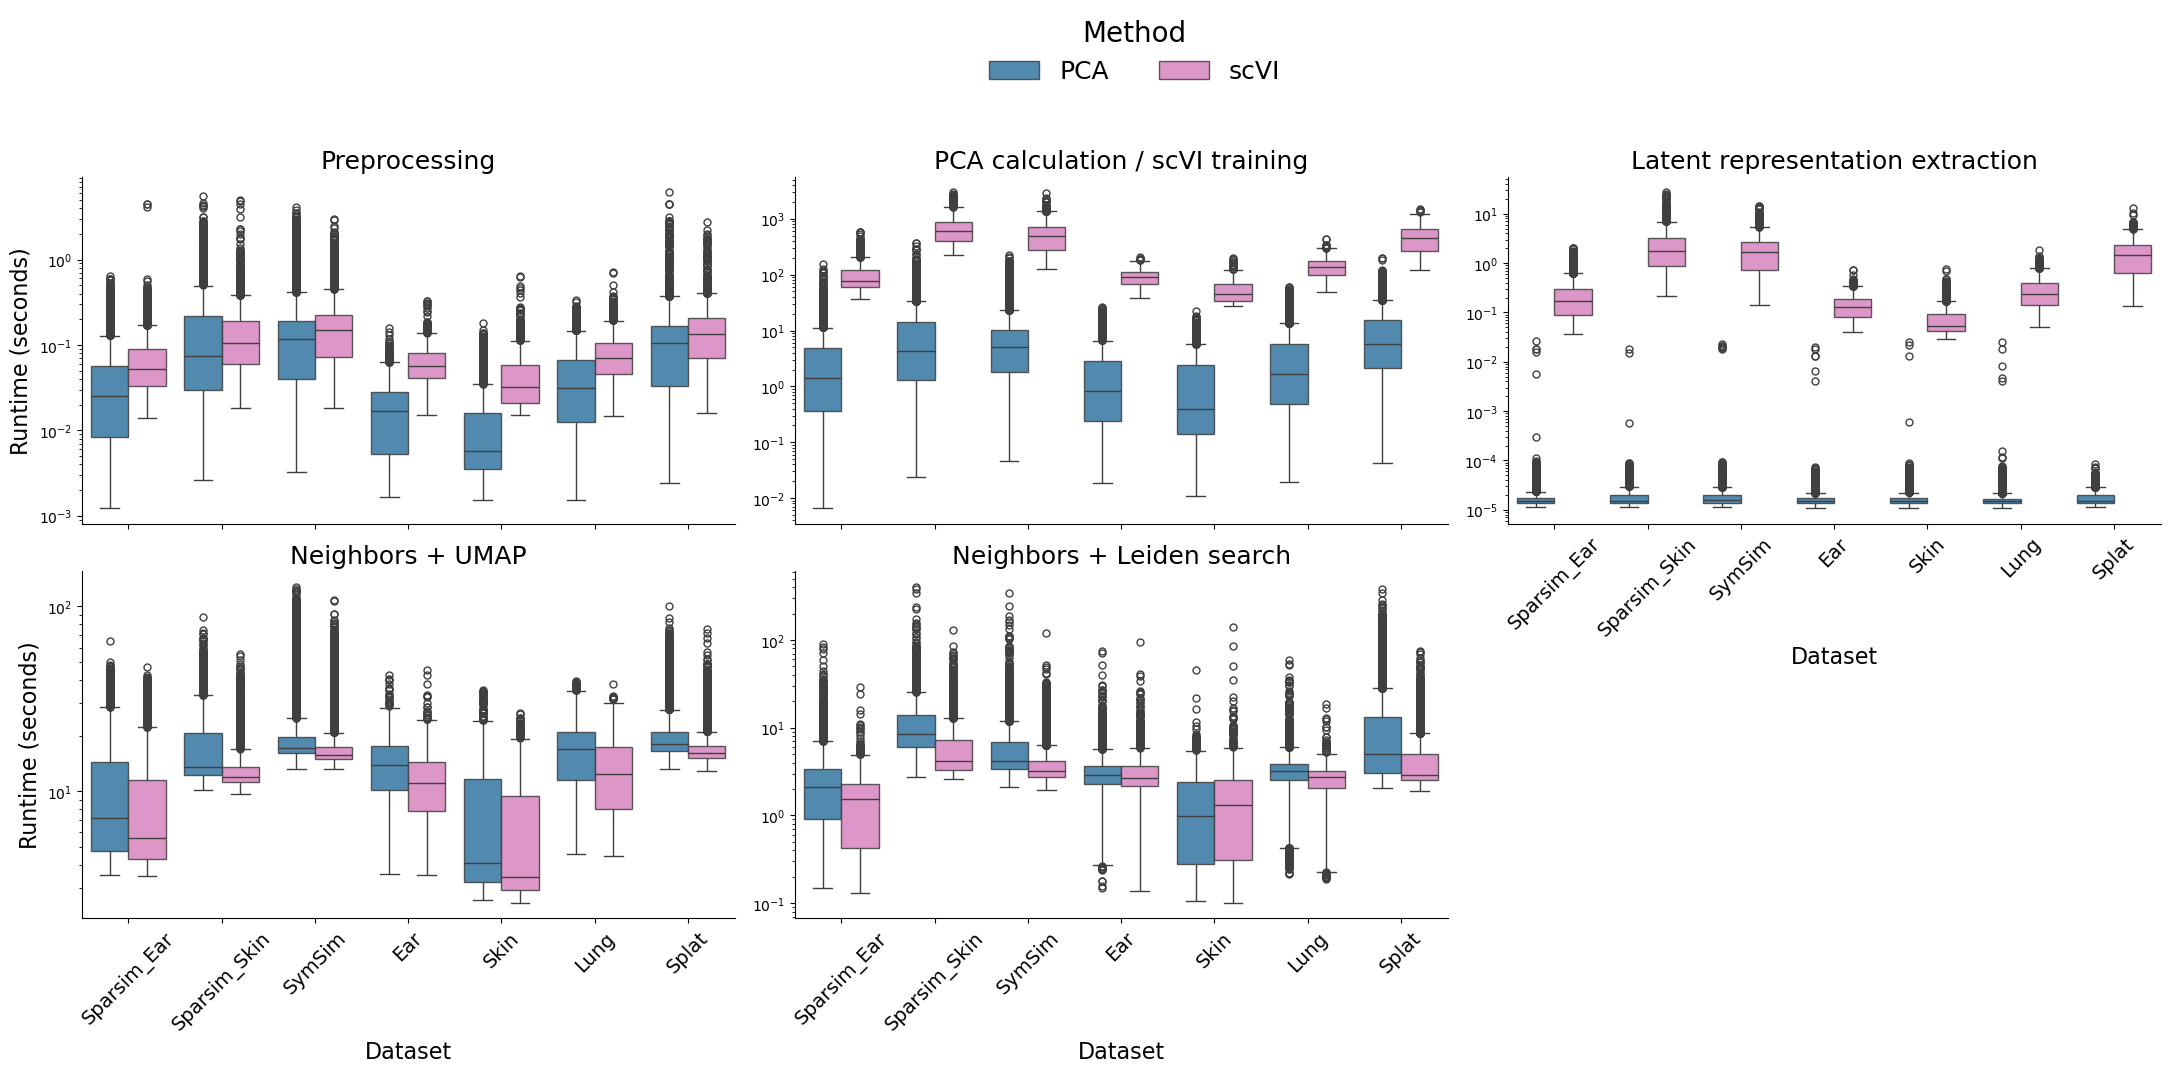

In [75]:
g = sns.catplot(
    data=df_long,
    kind="box",
    x="dataset",
    y="runtime",
    hue=pipeline_col,
    order=dataset_order,
    hue_order=method_order,
    col="pipeline_step_label",
    col_order=step_label_order,
    col_wrap=3,
    sharey=False,
    height=5,
    aspect=1.45,
    palette={
        "PCA": "#1F77B4",
        "scVI": "#E377C2",
    },
    boxprops={"alpha": 0.85},
)

g.set_axis_labels("Dataset", "Runtime (seconds)", size=16)
g.set_titles("{col_name}", size=18)

for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.tick_params(axis="x", labelsize=14, rotation=45)

# Remove the default legend
if g.legend is not None:
    g.legend.remove()

# Add the legend at the top
g.figure.legend(
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False,
    fontsize=18,
    title_fontsize=20,
)

g.figure.subplots_adjust(top=0.8)

plt.show()